Downloading bucket files: 38209567 / 38209567 complete

Downloading bytes: 38209567 / 38209567 complete

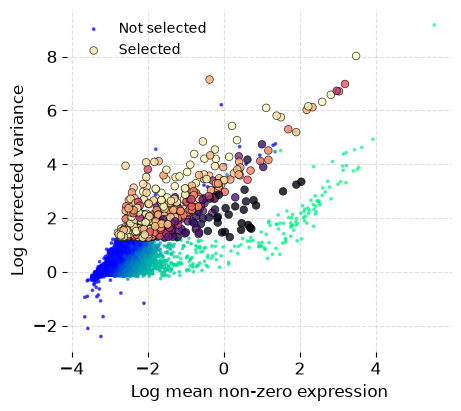

Selected genes: 500


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    show_plot=True,
    hvg_key_name="hvgs_500",
)
print(
    "Selected genes:",
    int(ds.RNA.feats.fetch_all("I__hvgs_500").sum()),
)

In [2]:
default_blacklist = (
    "^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|"
    "^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$"
)
exclusion_families = {
    "mitochondrial (MT-)": r"^MT-",
    "ribosomal protein (RPS/RPL)": r"^RPS|^RPL",
    "mitoribosomal (MRPS/MRPL)": r"^MRPS|^MRPL",
    "cell cycle (CCN)": r"^CCN",
    "HLA": r"^HLA-",
    "H2": r"^H2-",
    "histone (HIST)": r"^HIST",
    "sex-linked": (
        r"^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$"
        r"|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$"
    ),
}
family_counts = pd.Series(
    {
        name: len(ds.RNA.feats.grep(pattern))
        for name, pattern in exclusion_families.items()
    },
    name="genes matching pattern",
)
print(
    "Default blacklist matches:",
    len(ds.RNA.feats.grep(default_blacklist)),
)
family_counts

Default blacklist matches: 329


mitochondrial (MT-)             13
ribosomal protein (RPS/RPL)    104
mitoribosomal (MRPS/MRPL)       80
cell cycle (CCN)                31
HLA                             20
H2                               0
histone (HIST)                  71
sex-linked                      10
Name: genes matching pattern, dtype: int64

In [3]:
for key, kwargs in (
    ("hvgs_default", {}),
    ("hvgs_no_blacklist", {"blacklist": ""}),
):
    ds.mark_hvgs(
        min_cells=20,
        top_n=500,
        show_plot=False,
        hvg_key_name=key,
        **kwargs,
    )

pd.Series(
    {
        key: int(ds.RNA.feats.fetch_all(f"I__{key}").sum())
        for key in ("hvgs_default", "hvgs_no_blacklist")
    },
    name="selected genes",
)

hvgs_default         500
hvgs_no_blacklist    500
Name: selected genes, dtype: int64

In [4]:
feature_names = ds.RNA.feats.fetch_all("names")
only_without_blacklist = feature_names[
    ds.RNA.feats.fetch_all("I__hvgs_no_blacklist")
    & ~ds.RNA.feats.fetch_all("I__hvgs_default")
]
print("Genes selected only when blacklist is cleared:", len(only_without_blacklist))
pd.Series(only_without_blacklist).head(15)

Genes selected only when blacklist is cleared: 15


0          RPL5
1          RPSA
2     HIST1H2AC
3     HIST1H2BJ
4      HIST1H3H
5       HLA-DRA
6      HLA-DRB1
7      HLA-DQA1
8      HLA-DQB1
9       HLA-DMB
10      HLA-DMA
11     HLA-DPA1
12     HLA-DPB1
13       RPL10A
14         RPS5
dtype: object

In [5]:
for top_n, key in ((300, "hvgs_300"), (1000, "hvgs_1000")):
    ds.mark_hvgs(
        min_cells=20,
        top_n=top_n,
        show_plot=False,
        hvg_key_name=key,
    )
    ds.run_normalization(feat_key=key)
    ds.run_pca(dims=15)
    ds.build_embedding_initialization()
    ds.build_ann_index()
    ds.query_neighbors(k=11)
    ds.build_connectivity_map()
    ds.run_umap(
        n_epochs=150,
        spread=5,
        min_dist=1,
        parallel=True,
        label=f"{key}_UMAP",
    )
    ds.run_leiden_clustering(
        resolution=0.5,
        label=f"{key}_clusters",
    )

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

...

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 150 / 150 complete

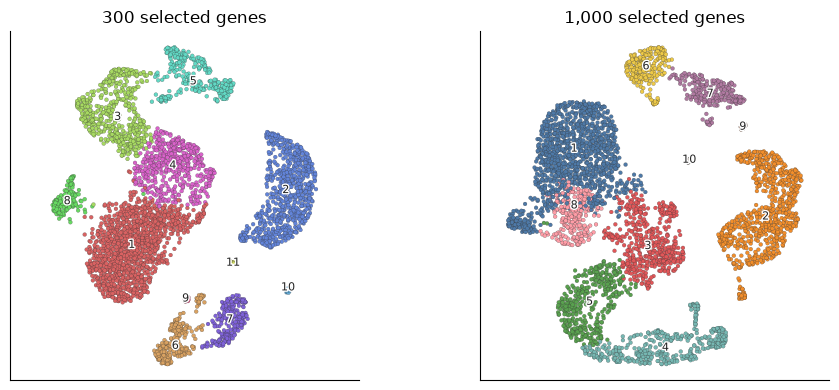

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, top_n in zip(axes, (300, 1000), strict=True):
    ds.plots.embedding(
        layout_key=f"RNA_hvgs_{top_n}_UMAP",
        color_by=f"RNA_hvgs_{top_n}_clusters",
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(f"{top_n:,} selected genes")
figure.tight_layout()
figure

In [7]:
pd.Series(
    {
        key: int(ds.RNA.feats.fetch_all(f"I__{key}").sum())
        for key in ("hvgs_300", "hvgs_1000")
    },
    name="selected genes",
)

hvgs_300      300
hvgs_1000    1000
Name: selected genes, dtype: int64

In [8]:
pd.DataFrame(
    {
        "300 genes": pd.Series(
            ds.cells.fetch("RNA_hvgs_300_clusters")
        ).value_counts().sort_index(),
        "1,000 genes": pd.Series(
            ds.cells.fetch("RNA_hvgs_1000_clusters")
        ).value_counts().sort_index(),
    }
)

,300 genes,"1,000 genes"
1,1239,1168.0
2,724,724.0
3,502,479.0
4,483,410.0
5,319,391.0
6,246,250.0
7,235,248.0
8,147,243.0
9,18,15.0
10,15,12.0


In [9]:
pd.crosstab(
    pd.Series(ds.cells.fetch("RNA_hvgs_300_clusters"), name="300 genes"),
    pd.Series(ds.cells.fetch("RNA_hvgs_1000_clusters"), name="1,000 genes"),
)

"1,000 genes",1,2,3,4,5,6,7,8,9,10
300 genes,,,,,,,,,,
1,1030,0,27,0,3,0,0,179,0,0
2,0,722,0,0,0,2,0,0,0,0
3,0,0,34,92,376,0,0,0,0,0
4,23,0,417,0,10,0,0,33,0,0
5,0,0,0,318,1,0,0,0,0,0
6,0,0,0,0,0,235,11,0,0,0
7,0,2,1,0,0,3,229,0,0,0
8,115,0,0,0,1,0,0,31,0,0
9,0,0,0,0,0,10,8,0,0,0


In [10]:
feature_set_partitions = [
    "RNA_hvgs_300_clusters",
    "RNA_hvgs_1000_clusters",
]
pd.Series(
    {
        "adjusted Rand index": ds.metric_label_concordance(
            feature_set_partitions,
            metric="ari",
        ),
        "normalized mutual information": ds.metric_label_concordance(
            feature_set_partitions,
            metric="nmi",
        ),
    },
    name="300 vs 1,000 selected genes",
)

adjusted Rand index              0.758730
normalized mutual information    0.814911
Name: 300 vs 1,000 selected genes, dtype: float64

In [11]:
panel_genes = ["CD3D", "MS4A1", "CD14", "LYZ", "NKG7", "GNLY"]
manual_mask = np.isin(
    ds.RNA.feats.fetch_all("names").astype(str),
    panel_genes,
)
print("mask length:", len(manual_mask), "selected:", int(manual_mask.sum()))
custom_feature_key = ds.set_hvgs(
    cell_key="I",
    mask=manual_mask,
    hvg_key_name="custom_features",
    blacklist="",
)
custom_feature_key, int(ds.RNA.feats.fetch_all(custom_feature_key).sum())

mask length: 33538 selected: 6


('I__custom_features', 6)